# Data Visualisation and Communication - Repeat
## Online Retail Analysis

## 1. Introduction
This notebook explores a real-world *Online Retail* dataset from a gift wholesaler, containing transactional data such as invoice numbers, product codes, descriptions, quantities, prices, timestamps, customer IDs and Countries. The company has grown quickly, and systematic data analysis has not been conducted as expected. Although the valuable insights provided on this assessment will help managers to visualise and understand which products drive revenue, which countries are most important, and how sales behave over time.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading and Initial Preparation

In [2]:
# Reading the dataset 
df = pd.read_excel('Online Retail.xlsx')

# print the first five rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2.1 Understanding Retail Dataset

In [3]:
# print the last rows of the dataset
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
# check the data shape
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [7]:
df.describe(include=object)

C:\Users\adeli\AppData\Local\Temp\ipykernel_13256\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [8]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [9]:
# Check the columns first
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
df['Country'].unique()

<ArrowStringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [11]:
df['InvoiceDate'].unique()

<DatetimeArray>
['2010-12-01 08:26:00', '2010-12-01 08:28:00', '2010-12-01 08:34:00',
 '2010-12-01 08:35:00', '2010-12-01 08:45:00', '2010-12-01 09:00:00',
 '2010-12-01 09:01:00', '2010-12-01 09:02:00', '2010-12-01 09:09:00',
 '2010-12-01 09:32:00',
 ...
 '2011-12-09 12:09:00', '2011-12-09 12:16:00', '2011-12-09 12:19:00',
 '2011-12-09 12:20:00', '2011-12-09 12:21:00', '2011-12-09 12:23:00',
 '2011-12-09 12:25:00', '2011-12-09 12:31:00', '2011-12-09 12:49:00',
 '2011-12-09 12:50:00']
Length: 23260, dtype: datetime64[us]

In [12]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

**Explanation:** The [us] indicates microsecond precision. It is a Pandas datetime type

In [13]:
# Check the date range of the dataset
print("First transaction date:", df['InvoiceDate'].min())
print("Last transaction date:", df['InvoiceDate'].max())

First transaction date: 2010-12-01 08:26:00
Last transaction date: 2011-12-09 12:50:00


### Invoice date data type
The 'InvoiceDate' column is already stored as a datetime data type. This is appropriate because it allows transactions to be grouped, filtered and visualised over time. It will later support analysis of monthly sales trends and use of date-range filters in the interactive dashboard.

The '.dt' operations only work properly when the column is a datetime. It shows that the dataset starts in December 2010 and ends in December 2011. 

In [14]:
#
df['InvoiceDate'].dt.year


0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
541904    2011
541905    2011
541906    2011
541907    2011
541908    2011
Name: InvoiceDate, Length: 541909, dtype: int32

In [15]:
#
df['InvoiceDate'].dt.month


0         12
1         12
2         12
3         12
4         12
          ..
541904    12
541905    12
541906    12
541907    12
541908    12
Name: InvoiceDate, Length: 541909, dtype: int32

In [16]:
# Check the months included in the dataset
sorted(df['InvoiceDate'].dt.month.unique())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

**Explanation:** The operation above checks month numbers by itself, but it does not distinguish between 2010 and 2011.

In [17]:
# Count transaction lines for each year and month
monthly_records = (
    df.assign(YearMonth=df['InvoiceDate'].dt.to_period('M'))
      .groupby('YearMonth')
      .size()
      .reset_index(name='NumberOfRecords')
)

monthly_records

,YearMonth,NumberOfRecords
0,2010-12,42481
1,2011-01,35147
2,2011-02,27707
3,2011-03,36748
4,2011-04,29916
5,2011-05,37030
6,2011-06,36874
7,2011-07,39518
8,2011-08,35284
9,2011-09,50226


**Explanation:** The transaction dates were grouped by year and month to confirm the period covered by the dataset. The output shows that November 2011 contains the highest number of records, with 84,711 rows.

The dataset begins on 1 December 2010 and ends on 9 December 2011. Therefore, December 2011 is an incomplete month, which explains its lower number of records. This limitation should be considered when comparing monthly sales. 


### Duplicate Rows
Check how many rows are completely duplicated in the dataset. The dataset contains 5268 exact duplicate rows. Exact duplicates were identified by comparing all eight columns. 
The additional inspection returned 10147 rows because 'keep=False' displays every row involved in a duplicate group, including the first occurrence and its matching copies. 
Exact duplicate records could cause quantities and sales revenue to be counted more than once. Therefore, one copy of each record will be retained and the additional duplicated rows will be removed during the data cleaning.

In [18]:
# Check for duplicate rows
df.duplicated().sum()

5268

In [19]:
# Show duplicated rows beside their matching copies
duplicate_rows = (
    df[df.duplicated(keep=False)]
    .sort_values(by=df.columns.tolist())
)

duplicate_rows.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [20]:
# Check the total of duplicate_rows
duplicate_rows.shape[0]

10147

### Initial Numeric Data Quality Checks

I reviewed the distribution of 'Quantity' and 'UnitPrice' and counted how many rows have non-positive values.

- Negative or zero quantities likely indicate cancelled orders, returns, or data entry errors.
- Zero or negative prices are also suspicious, as products are usually sold at a positive price.

In [26]:
# Check for numeric columns
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [27]:
# Check how many rows have non-positive quantity or price
(df['Quantity'] <= 0).sum(), (df['UnitPrice'] <=0).sum()

(10624, 2517)

**Explanation:**  Descriptive statistics were examined for the 'Quantity' and 'UnitPrice' columns. The output shows that 'Quantity' ranges from -80,995 to 80,995, while 'UnitPrice' ranges from -11,062.06 to 38,970. These very large minimum and maximum values suggest the presence of extreme values that require further investigation. 

There are 10624 records with a *quantity less than or equal to zero* and *2517 records with unitprice less than or equal to zero*. Negative quantities may represent product returns or cancelled transactions rather than completed sales. Zero or negative prices may represent free items, accounting adjustments or invalid sales records. These records will be examined before making a cleaning decision.


### Counting Missing values

In [21]:
# Count missing values per column
missing_counts = df.isnull().sum()
print(missing_counts)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [22]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_counts': df.isnull().sum(),
    'unique_values': df.nunique(dropna=False)
}).sort_values(by='missing_counts', ascending=False)

summary

,dtype,missing_counts,unique_values
CustomerID,float64,135080,4373
Description,object,1454,4224
InvoiceNo,object,0,25900
StockCode,object,0,4070
Quantity,int64,0,722
InvoiceDate,datetime64[us],0,23260
UnitPrice,float64,0,1630
Country,str,0,38


### Missing values
I checked the number of missing values per column. From this, I found that: 

- 'CustomerID' has 135080 missing values
- 'Description' has 1454 missing values

This indicates that customer information is incomplete for many transactions, which will affect any analysis by customer. In the Data cleaning section I will decide how to handle this.

### Summary of Initial Data Quality Issues

In [25]:
# Identify cancelled invoices
cancelled_mask = df['InvoiceNo'].str.startswith('C', na=False)

# Columns required for a valid transaction
essential_columns = [
    'InvoiceNo',
    'StockCode',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'Country'
]

issue_summary = pd.DataFrame({
    'Data Quality Issue': [
        'Complete duplicate rows',
        'Missing descriptions',
        'Missing CustomerID values',
        'Invalid or missing essential values',
        'Cancelled invoices',
        'Zero or negative quantities',
        'Zero or negative unit prices'
    ],
    'Rows Affected': [
        df.duplicated().sum(),
        df['Description'].isna().sum(),
        df['CustomerID'].isna().sum(),
        df[essential_columns].isna().any(axis=1).sum(),
        cancelled_mask.sum(),
        (df['Quantity'] <= 0).sum(),
        (df['UnitPrice'] <= 0).sum()
    ]
})

issue_summary

,Data Quality Issue,Rows Affected
0,Complete duplicate rows,5268
1,Missing descriptions,1454
2,Missing CustomerID values,135080
3,Invalid or missing essential values,0
4,Cancelled invoices,9288
5,Zero or negative quantities,10624
6,Zero or negative unit prices,2517


**Explanation:** This table summarises the main data quality issues identified in the original dataset before cleaning. Some categories may overlap, so the values should not be added together.

## 3. Data Cleaning

### 3.1 Create a Copy of the Dataset

A copy of the original dataset was created before cleaning. This preserves the raw data and makes it possible to compare the original and cleaned datasets without permanently changing the source data.

In [49]:
#
print("Original dataset shape:", df.shape)

Original dataset shape: (541909, 8)


In [32]:
# Create a copy for data cleaning
df_clean = df.copy()

### 3.2 Remove Duplicate Rows

In [33]:
# Remove exact duplicate rows and retain the first occurrence
df_clean = df_clean.drop_duplicates().copy()

In [36]:
# Show the shape of the staset after remove duplicate rows
print("Cleaned dataset shape:", df_clean.shape)

Cleaning dataset shape: (536641, 8)


In [38]:
# Check for duplicate rows after cleaning
df_clean.duplicated().sum()

0

**Explanation:** After removing exact duplicate rows, the dataset was reduced from 541,909 to 536,641 records. A second duplicate check returned zero, confirming that all exact duplicates were successfully removed.

### 3.3 Handle Missing Values

**Explanation:** The 'CustomerID' column contains 135,080 missing values. These rows were not removed because they still contain useful transaction information, including product, quantity, price, date and country. However, records without a CustomerID will not be used for customer analysis.

The 'Description' column contains 1,454 missing values. These records will be reviewed after cancelled and invalid transactions are handled, as some missing descriptions may relate to adjustments or non-standard transactions.

In [55]:
# Dataset for analyses requiring a known customer
df_clean = df_clean.dropna(subset=['CustomerID']).copy()

In [57]:
df_clean['Description'].isnull().sum()

0

In [58]:
df_clean['Description'] = df_clean['Description'].fillna('Unknown Product')

### 3.4 Investigate Cancelled Transactions and Returns

In [42]:
# Select invoice numbers beginning with 'C' 
cancelled_rows = df_clean[
    df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False)
].copy()

print("Number of cancelled transaction rows:", cancelled_rows.shape[0])

cancelled_rows.head()

Number of cancelled transaction rows: 9251


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


**Explanation:** The dataset contains 9,251 transaction rows where the InvoiceNo begins with 'C' and these transaction rows have negative quantities. This supports the interpretation that these records represent cancellations, returns or reversals rather than completed sales.
These records will be excluded from the main sales analysis because including them would reduce and distort the revenue calculated from the completed transactions.

In [45]:
# Record the number of rows before removing cancelled transactions
rows_before = len(df_clean)

# Remove invoices beginning with C from the dataset
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False)
].copy()

In [46]:
# Calculate the number of rows removed
cancelled_removed = rows_before - len(df_clean)

print("Cancelled rows removed:", cancelled_removed)
print("Rows remaining:", len(df_clean))

Cancelled rows removed: 9251
Rows remaining: 527390


In [48]:
# Confirm that cancelled invoices were removed
df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False).sum()

0

#### Result of Removing Cancelled Transactions
**Explanation:** 
A total of 9,251 cancelled transaction rows were removed from the dataset used for the main sales analysis. This reduced the dataset from 536,641 to 527,390 rows. The final check returned 0. Confirming that no invoice numbers beginning with 'C' remain in 'df_clean'.

These transactions are not necessarily data errors; they are valid records of cancellations or returns. However, they were excluded because the main analysis focuses on completed sales. The cancelled transactions remain stored separately in 'cancelled_rows' if they are needed for further analysis.

### Check Outliers


### 3.5 Handle Invalid Quantity and UnitPrice Values

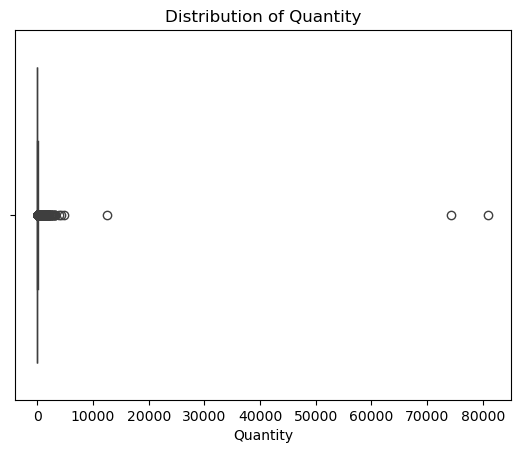

In [60]:
# Visualise possible quantity outliers
sns.boxplot(x=df_clean['Quantity'])

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.show()

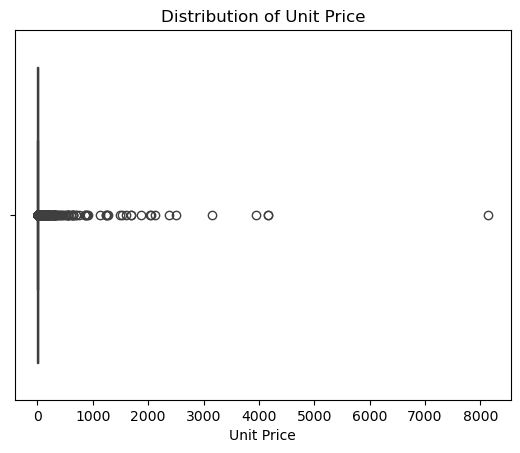

In [61]:
# Visualise possible UnitPrice outliers
sns.boxplot(x=df_clean['UnitPrice'])

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.show()

In [62]:
# Calculate the sales value of each transaction line
df_clean['TotalSales'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
).round(2)

df_clean[
    ['Quantity', 'UnitPrice', 'TotalSales']
].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 4. Exploratory Data Analysis (EDA)

### 4.1 Descriptive Stastistics

### 4.2 Line Chart - MOnthly Sales Revenue

- **Objective:**
- **Why this Plot:**
- **Learning:**

### 4.3 Horizontal Bar Chart - Top-Selling Products

- **Objective:**
- **Why this Plot:**
- **Learning:**

### 4.4 Bar Chart - Sales by Country

- **Objective:**
- **Why this Plot:**
- **Learning:**

### 4.5 Horizontal Bar Chart - Top Customers

- **Objective:**
- **Why this Plot:**
- **Learning:**

### 4.6 Histograma - Distribution of Sales Values

- **Objective:**
- **Why this Plot:**
- **Learning:**

### 4.7 Scatterplot - Quantity and Sales Value

- **Objective:**
- **Why this Plot:**
- **Learning:**